# CS610 Assignment 2 | Question 3: Multi-class classification

## Part 0: Setup and Imports

Install required libraries (run once on Colab).

In [1]:
!pip install torch optuna openpyxl scikit-learn matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.0 MB/s eta 0:00:00


Import all libraries used throughout this notebook.

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, f1_score, classification_report,
                             ConfusionMatrixDisplay, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


Using device: cuda


Create output folder structure for saving checkpoints, results, and plots.

In [11]:
BASE_DIR = '/content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment'
os.makedirs(f'{BASE_DIR}/outputs/checkpoints', exist_ok=True)
os.makedirs(f'{BASE_DIR}/outputs/results', exist_ok=True)
print("Folder structure created:")
for root, dirs, files in os.walk(f'{BASE_DIR}/outputs'):
    level = root.replace(f'{BASE_DIR}/outputs', '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")


Folder structure created:
outputs/
  checkpoints/
  results/


Mount Drive, Load Dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment

Mounted at /content/drive
/content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment


In [105]:
DATA_PATH = 'students_grades.xlsx'

df = pd.read_excel(DATA_PATH)

---
## Part 1: Exploratory Data Analysis (EDA)

Load the dataset and inspect its basic properties.

In [106]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
df.head()


Shape: 649 rows, 22 columns

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'romantic', 'famrel', 'health', 'absences', 'target']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,famsup,paid,activities,nursery,higher,romantic,famrel,health,absences,target
0,GP,F,18.0,U,GT3,A,4.0,4.0,17.7,209.0,...,no,no,no,yes,yes,no,good,fair,4.0,D
1,NaN,F,17.0,U,GT3,T,1.0,1.0,10.7,143.0,...,yes,no,no,no,yes,no,very good,fair,2.0,C
2,GP,F,15.0,U,LE3,T,1.0,1.0,8.6,133.0,...,no,no,no,yes,yes,no,good,fair,6.0,B
3,GP,F,15.0,U,GT3,NaN,4.0,2.0,7.4,546.0,...,yes,no,yes,yes,yes,yes,fair,very good,0.0,A
4,GP,F,16.0,U,GT3,T,NaN,3.0,7.3,204.0,...,yes,no,no,yes,yes,no,good,very good,0.0,B


Check data types and basic statistics for numerical columns.

In [107]:
print("Data types:")
print(df.dtypes)
print("\nNumerical summary:")
df.describe()


Data types:
school         object
sex            object
age           float64
address        object
famsize        object
Pstatus        object
Medu          float64
Fedu          float64
traveltime    float64
studytime     float64
failures      float64
schoolsup      object
famsup         object
paid           object
activities     object
nursery        object
higher         object
romantic       object
famrel         object
health         object
absences      float64
target         object
dtype: object

Numerical summary:


,age,Medu,Fedu,traveltime,studytime,failures,absences
count,633.000000,633.000000,639.000000,629.000000,634.000000,637.000000,635.000000
mean,16.747235,2.508689,2.306729,18.503021,240.735016,0.224490,3.694488
std,1.214077,1.136424,1.099930,16.276975,216.229551,0.597292,4.671332
min,15.000000,0.000000,0.000000,3.000000,5.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,8.700000,96.000000,0.000000,0.000000
50%,17.000000,2.000000,2.000000,13.500000,191.000000,0.000000,2.000000
75%,18.000000,4.000000,3.000000,23.800000,283.000000,0.000000,6.000000
max,22.000000,4.000000,4.000000,119.600000,1199.000000,3.000000,32.000000


Check the target variable distribution.

Target distribution:
target
A    162
B    162
C    162
D    163
Name: count, dtype: int64



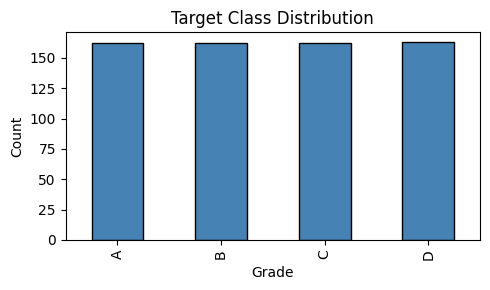

In [108]:
print("Target distribution:")
print(df['target'].value_counts().sort_index())
print()

fig, ax = plt.subplots(figsize=(5, 3))
df['target'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Target Class Distribution')
ax.set_xlabel('Grade')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


### Missing Value Analysis

We check missing values at two levels:
1. Per-feature missing count and percentage.
2. Total rows with at least one missing value as a percentage of all rows.

If the row-level missing percentage exceeds 5%, dropping rows is not viable and we should impute instead.

In [109]:
# Per-feature missing count and percentage
missing_info = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print("Missing values per feature:")
print(missing_info)

# Row-level: how many rows have at least one missing value
total_rows = len(df)
rows_with_missing = df.isnull().any(axis=1).sum()
pct_rows_missing = rows_with_missing / total_rows * 100

print(f"\nTotal rows: {total_rows}")
print(f"Rows with at least one missing value: {rows_with_missing} ({pct_rows_missing:.2f}%)")
print(f"Rows remaining if dropped: {total_rows - rows_with_missing}")

if pct_rows_missing > 5:
    print(f"\n>> {pct_rows_missing:.2f}% far exceeds the 5% threshold.")
    print(">> Dropping these rows would lose nearly half the dataset. We will impute instead.")
else:
    print(f"\n>> {pct_rows_missing:.2f}% is below 5%. Dropping rows is acceptable.")


Missing values per feature:
            Missing Count  Missing %
school                 13       2.00
sex                    10       1.54
age                    16       2.47
address                12       1.85
famsize                14       2.16
Pstatus                18       2.77
Medu                   16       2.47
Fedu                   10       1.54
traveltime             20       3.08
studytime              15       2.31
failures               12       1.85
schoolsup              13       2.00
famsup                 14       2.16
paid                   13       2.00
activities              9       1.39
nursery                 6       0.92
higher                 13       2.00
romantic               12       1.85
famrel                  9       1.39
health                 12       1.85
absences               14       2.16
target                  0       0.00

Total rows: 649
Rows with at least one missing value: 271 (41.76%)
Rows remaining if dropped: 378

>> 41.76% far exceeds

---
## Part 2: Data Preprocessing

### 2.1 Handle Missing Values via Imputation

Since 41.76% of rows contain at least one missing value (far exceeding the 5% threshold), we impute rather than drop:
- Numerical columns: fill with median (robust to outliers).
- Categorical columns: fill with mode (most frequent value). Even imputing categorical columns with mode value may introduce bias, but in this case,  each individual column has very low missing rates (1 to 3%), so the distortion per column is small even if it adds up across columns.

In [110]:
numerical_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'absences']
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
                    'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
                    'higher', 'romantic', 'famrel', 'health']

# Fill numerical with median
for col in numerical_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  {col}: filled {df[col].isnull().sum()} remaining NaNs with median={median_val}")

# Fill categorical with mode
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  {col}: filled with mode='{mode_val}'")

print(f"\nTotal missing values after imputation: {df.isnull().sum().sum()}")


  age: filled 0 remaining NaNs with median=17.0
  Medu: filled 0 remaining NaNs with median=2.0
  Fedu: filled 0 remaining NaNs with median=2.0
  traveltime: filled 0 remaining NaNs with median=13.5
  studytime: filled 0 remaining NaNs with median=191.0
  failures: filled 0 remaining NaNs with median=0.0
  absences: filled 0 remaining NaNs with median=2.0
  school: filled with mode='GP'
  sex: filled with mode='F'
  address: filled with mode='U'
  famsize: filled with mode='GT3'
  Pstatus: filled with mode='T'
  schoolsup: filled with mode='no'
  famsup: filled with mode='yes'
  paid: filled with mode='no'
  activities: filled with mode='no'
  nursery: filled with mode='yes'
  higher: filled with mode='yes'
  romantic: filled with mode='no'
  famrel: filled with mode='good'
  health: filled with mode='very good'

Total missing values after imputation: 0


### 2.2 Encode Features

- Binary categorical columns: label encode to 0/1.
- Ordinal columns (`famrel`, `health`): map to numeric scale (1=very bad to 5=very good).
- Target: A=0, B=1, C=2, D=3.

In [111]:
# Binary categorical columns
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
               'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
               'higher', 'romantic']

le_dict = {}
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Ordinal columns
ordinal_map = {'very bad': 1, 'bad': 2, 'fair': 3, 'good': 4, 'very good': 5}
df['famrel'] = df['famrel'].map(ordinal_map)
df['health'] = df['health'].map(ordinal_map)
print(f"\n  famrel, health: very bad=1, bad=2, fair=3, good=4, very good=5")

# Target
target_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
df['target'] = df['target'].map(target_map)
print(f"  target: {target_map}")

print("\nEncoded data sample:")
df.head()


  school: {'GP': np.int64(0), 'MS': np.int64(1)}
  sex: {'F': np.int64(0), 'M': np.int64(1)}
  address: {'R': np.int64(0), 'U': np.int64(1)}
  famsize: {'GT3': np.int64(0), 'LE3': np.int64(1)}
  Pstatus: {'A': np.int64(0), 'T': np.int64(1)}
  schoolsup: {'no': np.int64(0), 'yes': np.int64(1)}
  famsup: {'no': np.int64(0), 'yes': np.int64(1)}
  paid: {'no': np.int64(0), 'yes': np.int64(1)}
  activities: {'no': np.int64(0), 'yes': np.int64(1)}
  nursery: {'no': np.int64(0), 'yes': np.int64(1)}
  higher: {'no': np.int64(0), 'yes': np.int64(1)}
  romantic: {'no': np.int64(0), 'yes': np.int64(1)}

  famrel, health: very bad=1, bad=2, fair=3, good=4, very good=5
  target: {'A': 0, 'B': 1, 'C': 2, 'D': 3}

Encoded data sample:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,famsup,paid,activities,nursery,higher,romantic,famrel,health,absences,target
0,0,0,18.0,1,0,0,4.0,4.0,17.7,209.0,...,0,0,0,1,1,0,4,3,4.0,3
1,0,0,17.0,1,0,1,1.0,1.0,10.7,143.0,...,1,0,0,0,1,0,5,3,2.0,2
2,0,0,15.0,1,1,1,1.0,1.0,8.6,133.0,...,0,0,0,1,1,0,4,3,6.0,1
3,0,0,15.0,1,0,1,4.0,2.0,7.4,546.0,...,1,0,1,1,1,1,3,5,0.0,0
4,0,0,16.0,1,0,1,2.0,3.0,7.3,204.0,...,1,0,0,1,1,0,4,5,0.0,1


### 2.3 Stratified 60:20:20 Train / Validation / Test Split

We use stratified sampling to maintain class balance across all three splits.

In [112]:
X = df.drop('target', axis=1).values
y = df['target'].values

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=SEED, stratify=y
)

# Second split: split 40% into 20%/20%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")
print(f"\nTrain target distribution: {np.bincount(y_train)}")
print(f"Val target distribution:   {np.bincount(y_val)}")
print(f"Test target distribution:  {np.bincount(y_test)}")


Train: 389 samples
Val:   130 samples
Test:  130 samples

Train target distribution: [97 97 97 98]
Val target distribution:   [32 33 32 33]
Test target distribution:  [33 32 33 32]


### 2.4 Feature Scaling with StandardScaler

StandardScaler transforms each feature to have mean=0 and std=1: `z = (x - mean) / std`.

Neural networks learn through gradient descent. If features have very different scales (e.g., `absences` ranges 0 to 32 while binary columns are 0/1), the gradients will be dominated by large-scale features, causing slow and unstable convergence. Scaling puts all features on a comparable range.

The scaler is fitted on the training set only, then applied to validation and test sets to prevent data leakage.

In [113]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Convert data to PyTorch tensors and create DataLoaders.

In [114]:
def create_dataloaders(X_tr, y_tr, X_v, y_v, X_te, y_te, batch_size=32):
    """Helper function to create DataLoaders from numpy arrays.
    Reusable across parts 3(a) and 3(b)."""
    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    val_ds   = TensorDataset(torch.FloatTensor(X_v),  torch.LongTensor(y_v))
    test_ds  = TensorDataset(torch.FloatTensor(X_te), torch.LongTensor(y_te))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = create_dataloaders(
    X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test
)
print(f"DataLoaders created (batch_size=32)")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")


DataLoaders created (batch_size=32)
  Train batches: 13
  Val batches:   5
  Test batches:  5


In [115]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,famsup,paid,activities,nursery,higher,romantic,famrel,health,absences,target
0,0,0,18.0,1,0,0,4.0,4.0,17.7,209.0,...,0,0,0,1,1,0,4,3,4.0,3
1,0,0,17.0,1,0,1,1.0,1.0,10.7,143.0,...,1,0,0,0,1,0,5,3,2.0,2
2,0,0,15.0,1,1,1,1.0,1.0,8.6,133.0,...,0,0,0,1,1,0,4,3,6.0,1
3,0,0,15.0,1,0,1,4.0,2.0,7.4,546.0,...,1,0,1,1,1,1,3,5,0.0,0
4,0,0,16.0,1,0,1,2.0,3.0,7.3,204.0,...,1,0,0,1,1,0,4,5,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,1,0,19.0,0,0,1,2.0,3.0,5.7,487.0,...,0,0,1,0,1,0,5,5,4.0,2
645,1,0,18.0,1,1,1,3.0,1.0,9.9,262.0,...,1,0,0,1,1,0,4,1,4.0,0
646,1,0,18.0,1,0,1,1.0,1.0,13.5,288.0,...,0,0,1,1,1,0,1,5,6.0,2
647,1,1,17.0,1,1,1,3.0,1.0,20.9,99.0,...,0,0,0,0,1,0,2,2,6.0,2


---
## Part 3: Question 3(a) - Baseline Single-Hidden-Layer Neural Network

Build a neural network with a single hidden layer. Performance does not matter for this part.
We report the confusion matrix and macro F1 score, along with additional metrics.

### 3.1 Define the Model

A feedforward network with:
- Input layer: 21 features
- One hidden layer: 64 neurons with ReLU activation
- Output layer: 4 nodes (one per grade class)

CrossEntropyLoss in PyTorch applies softmax internally, so the output layer produces raw logits.

In [116]:
class SingleHiddenLayerNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SingleHiddenLayerNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

INPUT_DIM = X_train_scaled.shape[1]  # 21 features
HIDDEN_DIM = 64
OUTPUT_DIM = 4  # A, B, C, D

model_a = SingleHiddenLayerNN(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM).to(DEVICE)
print(model_a)
print(f"\nTotal parameters: {sum(p.numel() for p in model_a.parameters())}")


SingleHiddenLayerNN(
  (fc1): Linear(in_features=21, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)

Total parameters: 1668


### 3.2 Train the Model

We use CrossEntropyLoss and the Adam optimizer. Adam (Adaptive Moment Estimation) combines momentum and adaptive per-parameter learning rates, making it converge faster than basic SGD in most cases. It is the most commonly used default optimizer in PyTorch.

We track training and validation loss across epochs to monitor for overfitting.

In [117]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=100, device=DEVICE, verbose_every=20):
    """Training loop. Returns train/val loss history.
    Reusable across parts 3(a) and 3(b)."""
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * X_batch.size(0)
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation phase
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                epoch_val_loss += loss.item() * X_batch.size(0)
        epoch_val_loss /= len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if verbose_every and (epoch + 1) % verbose_every == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {epoch_train_loss:.4f}  Val Loss: {epoch_val_loss:.4f}")

    return train_losses, val_losses

criterion_a = nn.CrossEntropyLoss()
optimizer_a = optim.Adam(model_a.parameters(), lr=0.001)

train_losses_a, val_losses_a = train_model(
    model_a, train_loader, val_loader, criterion_a, optimizer_a, num_epochs=100
)


Epoch [20/100] Train Loss: 0.9504  Val Loss: 1.2451
Epoch [40/100] Train Loss: 0.7922  Val Loss: 1.3368
Epoch [60/100] Train Loss: 0.6590  Val Loss: 1.4531
Epoch [80/100] Train Loss: 0.5455  Val Loss: 1.5779
Epoch [100/100] Train Loss: 0.4557  Val Loss: 1.7373


### 3.3 Plot Training and Validation Loss

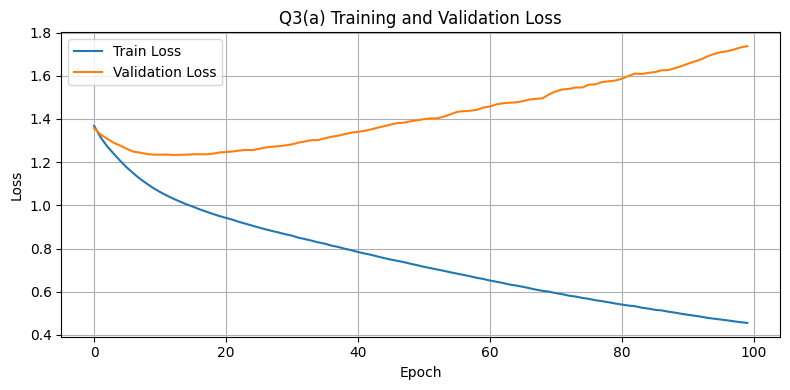

In [118]:
def plot_losses(train_losses, val_losses, title='Training and Validation Loss',
                save_path=None):
    """Plot loss curves. Reusable across parts."""
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_losses(train_losses_a, val_losses_a,
            title='Q3(a) Training and Validation Loss',
            save_path='outputs/plots/q3a_loss_curve.png')


### 3.4 Evaluate on Test Set

We evaluate the trained model and report:
- **Confusion matrix**: prediction vs actual for each class.
- **Macro F1 score**: unweighted mean of per-class F1, treating all classes equally.
- **Overall accuracy**: proportion of correct predictions.
- **Per-class accuracy**: diagonal of confusion matrix divided by class support.
- **Classification report**: precision, recall, and F1 per class.

Confusion matrix saved to outputs/results/q3a_confusion_matrix.png


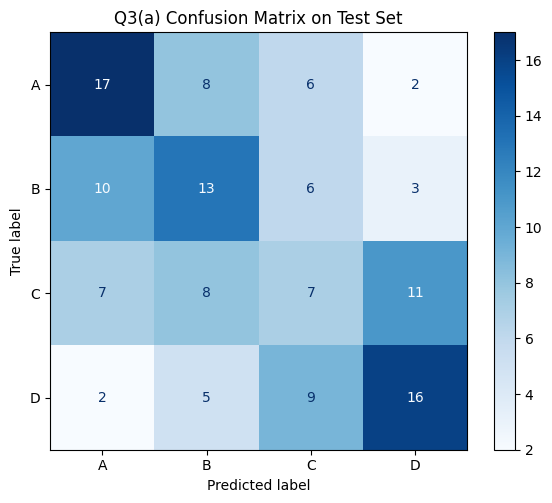

Macro F1 Score:   0.4041
Overall Accuracy: 0.4077

Per-class Accuracy:
  Class A: 0.5152
  Class B: 0.4062
  Class C: 0.2121
  Class D: 0.5000

Classification Report:
              precision    recall  f1-score   support

           A       0.47      0.52      0.49        33
           B       0.38      0.41      0.39        32
           C       0.25      0.21      0.23        33
           D       0.50      0.50      0.50        32

    accuracy                           0.41       130
   macro avg       0.40      0.41      0.40       130
weighted avg       0.40      0.41      0.40       130

Report saved to outputs/results/q3a_classification_report.txt


In [119]:
CLASS_NAMES = ['A', 'B', 'C', 'D']

def evaluate_model(model, test_loader, class_names=CLASS_NAMES, device=DEVICE,
                   title='Confusion Matrix', save_cm_path=None, save_report_path=None):
    """Full evaluation: confusion matrix, F1, accuracy, classification report.
    Reusable across parts."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    if save_cm_path:
        plt.savefig(save_cm_path, dpi=150)
        print(f"Confusion matrix saved to {save_cm_path}")
    plt.show()

    # Metrics
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    print(f"Macro F1 Score:   {macro_f1:.4f}")
    print(f"Overall Accuracy: {acc:.4f}")

    # Per-class accuracy
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    print("\nPer-class Accuracy:")
    for name, pa in zip(class_names, per_class_acc):
        print(f"  Class {name}: {pa:.4f}")

    # Classification report
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(f"\nClassification Report:\n{report}")

    # Save report to text file
    if save_report_path:
        with open(save_report_path, 'w') as f:
            f.write(f"Macro F1 Score:   {macro_f1:.4f}\n")
            f.write(f"Overall Accuracy: {acc:.4f}\n\n")
            f.write("Per-class Accuracy:\n")
            for name, pa in zip(class_names, per_class_acc):
                f.write(f"  Class {name}: {pa:.4f}\n")
            f.write(f"\nClassification Report:\n{report}")
        print(f"Report saved to {save_report_path}")

    return all_preds, all_labels

preds_a, labels_a = evaluate_model(
    model_a, test_loader,
    title='Q3(a) Confusion Matrix on Test Set',
    save_cm_path='outputs/results/q3a_confusion_matrix.png',
    save_report_path='outputs/results/q3a_classification_report.txt'
)


Results Summary

**Overall performance is poor.** The model achieves a **macro F1 of 0.39** and **accuracy of 39.2%**, barely above the **25% random baseline** for a balanced 4-class problem. This is expected since no tuning or regularization was applied.

**Class C is the hardest to predict**, with the lowest accuracy (**24.2%**) and F1 (**0.26**). Actual C samples are scattered across all predicted classes, meaning the model fails to find a clear pattern for this grade.

**Adjacent classes are heavily confused.** The confusion matrix shows frequent misclassification between neighboring grades (A vs B, C vs D). This is expected because **adjacent grades represent students with similar underlying scores**, making the boundaries inherently fuzzy.

**The model is severely overfitting.** Training loss drops to near zero while validation loss increases continuously from epoch 0 onward. With only **389 training samples**, **64 hidden neurons**, and **no regularization** (no dropout, no weight decay, no early stopping), the model memorizes the training set rather than learning generalizable patterns.

Save the baseline model checkpoint.

In [120]:
torch.save(model_a.state_dict(), 'outputs/checkpoints/q3a_baseline_model.pth')
print("Model saved to outputs/checkpoints/q3a_baseline_model.pth")


Model saved to outputs/checkpoints/q3a_baseline_model.pth


---
## Part 4: Question 3(b) - Hyperparameter Tuning with Optuna

Use Optuna to perform hyperparameter tuning on the single-hidden-layer neural network. We explore hidden layer size, learning rate, dropout, weight decay, batch size, and number of epochs. We run 200 trials optimizing validation macro F1, then retrain with the best hyperparameters and evaluate on the test set.

Import Optuna.

In [121]:
import optuna
from optuna.exceptions import TrialPruned
print(f"Optuna version: {optuna.__version__}")


Optuna version: 4.9.0


### 4.1 Define the Model with Dropout

We extend the baseline model by adding a **dropout layer** after the hidden layer. Dropout randomly zeroes out a fraction of neurons during training, which acts as regularization and helps reduce the overfitting we observed in Q3(a).

In [122]:
class TunableNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.0):
        super(TunableNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


### 4.2 Define the Optuna Objective Function

Each trial:
1. Samples a set of hyperparameters.
2. Builds a model and trains it on the training set.
3. Uses **early stopping** on validation loss (patience of 15 epochs) to avoid wasting time.
4. Returns the **validation macro F1 score** as the metric to maximize.

Hyperparameters explored:
- `hidden_dim`: 16 to 256
- `learning_rate`: 1e-4 to 1e-2 (log scale)
- `dropout_rate`: 0.0 to 0.5
- `weight_decay`: 1e-6 to 1e-2 (log scale)
- `batch_size`: 16, 32, or 64
- `num_epochs`: 50 to 300

In [123]:
def objective(trial):
    # Sample hyperparameters
    hidden_dim = trial.suggest_int('hidden_dim', 16, 256)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    num_epochs = trial.suggest_int('num_epochs', 50, 300)

    # Create DataLoaders with sampled batch size
    train_ld, val_ld, _ = create_dataloaders(
        X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test,
        batch_size=batch_size
    )

    # Build model
    model = TunableNN(INPUT_DIM, hidden_dim, OUTPUT_DIM, dropout_rate).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Training with early stopping
    best_val_loss = float('inf')
    patience = 15
    patience_counter = 0

    for epoch in range(num_epochs):
        # Train
        model.train()
        for X_batch, y_batch in train_ld:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        # Validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_ld:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss += criterion(model(X_batch), y_batch).item() * X_batch.size(0)
        val_loss /= len(val_ld.dataset)

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

        # Optuna pruning (stop unpromising trials early)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise TrialPruned()

    # Compute validation macro F1
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in val_ld:
            X_batch = X_batch.to(DEVICE)
            _, predicted = torch.max(model(X_batch), 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return macro_f1


### 4.3 Run Optuna Study

We maximize the validation macro F1 score. The MedianPruner stops unpromising trials early based on intermediate validation loss values.

In [131]:
study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20),
    study_name='q3b_nn_tuning'
)

study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"\nNumber of finished trials: {len(study.trials)}")
print(f"Best trial macro F1: {study.best_trial.value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")


[I 2026-06-16 05:46:15,559] A new study created in memory with name: q3b_nn_tuning


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-06-16 05:46:18,051] Trial 0 finished with value: 0.4321565758185476 and parameters: {'hidden_dim': 34, 'learning_rate': 0.00039684177576348437, 'dropout_rate': 0.32096165047651737, 'weight_decay': 0.0036128594760198992, 'batch_size': 16, 'num_epochs': 196}. Best is trial 0 with value: 0.4321565758185476.
[I 2026-06-16 05:46:19,524] Trial 1 finished with value: 0.40756613923658136 and parameters: {'hidden_dim': 219, 'learning_rate': 0.00026954173751703614, 'dropout_rate': 0.2869291265086332, 'weight_decay': 1.0903852554146757e-06, 'batch_size': 16, 'num_epochs': 154}. Best is trial 0 with value: 0.4321565758185476.
[I 2026-06-16 05:46:20,391] Trial 2 finished with value: 0.40363383437182354 and parameters: {'hidden_dim': 187, 'learning_rate': 0.001306797656777009, 'dropout_rate': 0.04859528229663479, 'weight_decay': 3.6565513705435455e-06, 'batch_size': 16, 'num_epochs': 218}. Best is trial 0 with value: 0.4321565758185476.
[I 2026-06-16 05:46:20,849] Trial 3 finished with value

### 4.4 Visualize Optuna Results

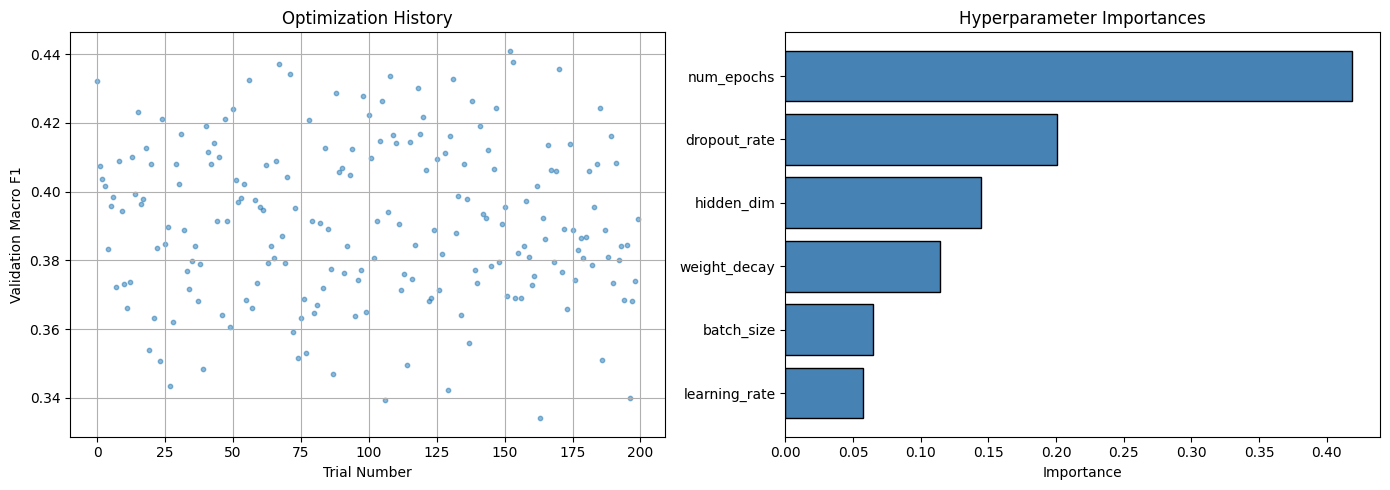

In [132]:
# Optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Trial values over time
trial_numbers = [t.number for t in study.trials if t.value is not None]
trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].scatter(trial_numbers, trial_values, alpha=0.5, s=10)
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Validation Macro F1')
axes[0].set_title('Optimization History')
axes[0].grid(True)

# Plot 2: Hyperparameter importances
importances = optuna.importance.get_param_importances(study)
params = list(importances.keys())
values = list(importances.values())
axes[1].barh(params, values, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importances')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


### 4.5 Retrain with Best Hyperparameters

Using the best hyperparameters found by Optuna, we retrain the model from scratch. This time we train the full number of epochs with early stopping, and save the best model state based on validation loss.

In [133]:
best_params = study.best_trial.params

print("Retraining with best hyperparameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Create DataLoaders with best batch size
train_loader_b, val_loader_b, test_loader_b = create_dataloaders(
    X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test,
    batch_size=best_params['batch_size']
)

# Build model with best hyperparameters
model_b = TunableNN(
    INPUT_DIM,
    best_params['hidden_dim'],
    OUTPUT_DIM,
    best_params['dropout_rate']
).to(DEVICE)

criterion_b = nn.CrossEntropyLoss()
optimizer_b = optim.Adam(
    model_b.parameters(),
    lr=best_params['learning_rate'],
    weight_decay=best_params['weight_decay']
)

# Train with early stopping based on validation macro F1
best_val_f1 = 0.0
patience = 30
patience_counter = 0
best_model_state = None
train_losses_b = []
val_losses_b = []

for epoch in range(best_params['num_epochs']):
    # Training phase
    model_b.train()
    epoch_train_loss = 0.0
    for X_batch, y_batch in train_loader_b:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_b.zero_grad()
        outputs = model_b(X_batch)
        loss = criterion_b(outputs, y_batch)
        loss.backward()
        optimizer_b.step()
        epoch_train_loss += loss.item() * X_batch.size(0)
    epoch_train_loss /= len(train_loader_b.dataset)
    train_losses_b.append(epoch_train_loss)

    # Validation phase
    model_b.eval()
    epoch_val_loss = 0.0
    val_preds = []
    val_labels = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader_b:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model_b(X_batch)
            loss = criterion_b(outputs, y_batch)
            epoch_val_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())
    epoch_val_loss /= len(val_loader_b.dataset)
    val_losses_b.append(epoch_val_loss)

    # Early stopping based on validation macro F1
    val_f1 = f1_score(val_labels, val_preds, average='macro')
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = {k: v.clone() for k, v in model_b.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{best_params['num_epochs']}] "
              f"Train Loss: {epoch_train_loss:.4f}  Val Loss: {epoch_val_loss:.4f}  Val F1: {val_f1:.4f}")

# Load the best model state
model_b.load_state_dict(best_model_state)
print(f"\nBest validation macro F1: {best_val_f1:.4f}")

Retraining with best hyperparameters:
  hidden_dim: 33
  learning_rate: 0.0011854487028035746
  dropout_rate: 0.3043870903571839
  weight_decay: 0.00010126846179360915
  batch_size: 32
  num_epochs: 246
Epoch [50/246] Train Loss: 0.9169  Val Loss: 1.2640  Val F1: 0.4025
Epoch [100/246] Train Loss: 0.8158  Val Loss: 1.3681  Val F1: 0.4579
Early stopping at epoch 129

Best validation macro F1: 0.4596


### 4.6 Plot Training and Validation Loss (Tuned Model)

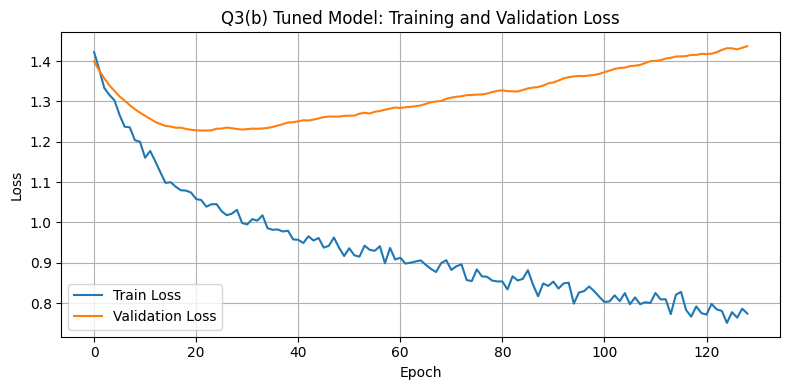

In [134]:
plot_losses(train_losses_b, val_losses_b,
            title='Q3(b) Tuned Model: Training and Validation Loss')


### 4.7 Evaluate Tuned Model on Test Set

Confusion matrix saved to /content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment/outputs/results/q3b_confusion_matrix.png


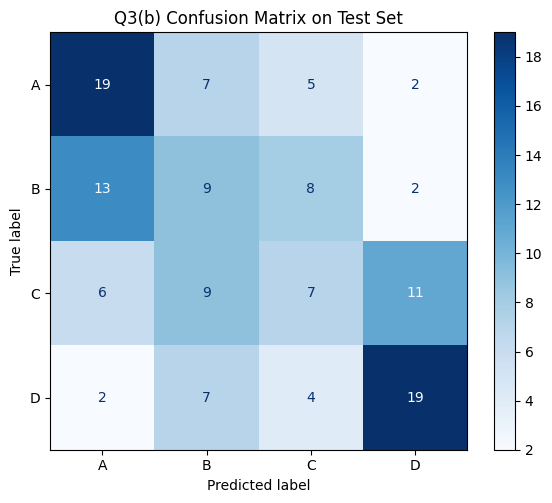

Macro F1 Score:   0.4058
Overall Accuracy: 0.4154

Per-class Accuracy:
  Class A: 0.5758
  Class B: 0.2812
  Class C: 0.2121
  Class D: 0.5938

Classification Report:
              precision    recall  f1-score   support

           A       0.47      0.58      0.52        33
           B       0.28      0.28      0.28        32
           C       0.29      0.21      0.25        33
           D       0.56      0.59      0.58        32

    accuracy                           0.42       130
   macro avg       0.40      0.42      0.41       130
weighted avg       0.40      0.42      0.41       130

Report saved to /content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment/outputs/results/q3b_classification_report.txt


In [135]:
preds_b, labels_b = evaluate_model(
    model_b, test_loader_b,
    title='Q3(b) Confusion Matrix on Test Set',
    save_cm_path=f'{BASE_DIR}/outputs/results/q3b_confusion_matrix.png',
    save_report_path=f'{BASE_DIR}/outputs/results/q3b_classification_report.txt'
)


### 4.8 Compare Q3(a) Baseline vs Q3(b) Tuned Model

In [136]:
f1_a = f1_score(labels_a, preds_a, average='macro')
f1_b = f1_score(labels_b, preds_b, average='macro')
acc_a = accuracy_score(labels_a, preds_a)
acc_b = accuracy_score(labels_b, preds_b)

print("Comparison: Q3(a) Baseline vs Q3(b) Tuned")
print(f"{'Metric':<20} {'Baseline':>10} {'Tuned':>10} {'Improvement':>12}")
print("-" * 55)
print(f"{'Macro F1':<20} {f1_a:>10.4f} {f1_b:>10.4f} {f1_b - f1_a:>+12.4f}")
print(f"{'Accuracy':<20} {acc_a:>10.4f} {acc_b:>10.4f} {acc_b - acc_a:>+12.4f}")


Comparison: Q3(a) Baseline vs Q3(b) Tuned
Metric                 Baseline      Tuned  Improvement
-------------------------------------------------------
Macro F1                 0.4041     0.4058      +0.0017
Accuracy                 0.4077     0.4154      +0.0077


Save the tuned model checkpoint.

In [130]:
torch.save(model_b.state_dict(), f'{BASE_DIR}/outputs/checkpoints/q3b_tuned_model.pth')
print(f"Tuned model saved to {BASE_DIR}/outputs/checkpoints/q3b_tuned_model.pth")


Tuned model saved to /content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment/outputs/checkpoints/q3b_tuned_model.pth
